# Gradient Boosting Classification

Ноутбук:
- как деревья строятся последовательно
- как каждое следующее дерево исправляет ошибки предыдущего
- Влияние `n_estimators` (количество деревьев), `learning_rate` (шаг обучения), `max_depth` (глубины)
- метрики и визуализации (decision boundary, ROC, confusion matrix, feature importance и т.д.)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, log_loss,
                             confusion_matrix, roc_curve)
from lightgbm import LGBMClassifier

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 5)


## 1. Данные

Сгенерируем датасет для бинарной классификации.


In [2]:
X, y = make_classification(
    n_samples=2000, n_features=10, n_informative=6,
    n_redundant=2, n_classes=2, random_state=42
)
feature_names = [f"f{i}" for i in range(X.shape[1])]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)
pd.DataFrame(X_train, columns=feature_names).head()


Train: (1500, 10) Test: (500, 10)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9
0,-0.028025,-0.976213,0.854369,-1.124674,-2.167467,-2.501343,0.905060,2.069948,-0.450695,0.288960
1,1.997813,0.080464,-2.617113,-3.675335,-3.649528,-2.103539,3.671003,0.134940,1.440290,-2.177011
2,1.567209,-1.036316,0.738566,5.617698,2.076177,0.593312,1.547304,0.598595,-0.324410,-0.111891
3,1.705389,-0.228450,0.169403,0.211089,-0.689142,1.823305,1.947621,-1.604804,-1.685734,-1.809746
4,0.109459,-0.177746,0.705149,-0.186769,0.525840,-1.791837,-1.962894,-0.415091,2.277420,-0.027220


## 2. Как бустинг строит деревья последовательно

Идея: каждое следующее дерево обучается на **остатках** (ошибках) предыдущей модели.
Покажем это вручную на 2D-датасете `make_moons` — будем складывать предсказания деревьев одно за другим.


In [3]:
X2, y2 = make_moons(n_samples=500, noise=0.3, random_state=42)

def manual_gb(X, y, n_trees=50, lr=0.3, max_depth=2):
    p = np.clip(y.mean(), 1e-6, 1-1e-6)
    F = np.full(len(y), np.log(p / (1 - p)))
    trees = []
    for _ in range(n_trees):
        prob = 1 / (1 + np.exp(-F))
        residual = y - prob
        tree = DecisionTreeRegressor(max_depth=max_depth)
        tree.fit(X, residual)
        F += lr * tree.predict(X)
        trees.append(tree)
    return trees, F

trees, F_final = manual_gb(X2, y2, n_trees=50, lr=0.3, max_depth=2)
prob_final = 1 / (1 + np.exp(-F_final))
print("Train accuracy:", accuracy_score(y2, (prob_final > 0.5).astype(int)))


Train accuracy: 0.9


### Как меняется decision boundary с добавлением деревьев

Видно, как с ростом числа деревьев граница становится точнее — каждое следующее дерево «дотягивает» те зоны, где модель ошибалась.


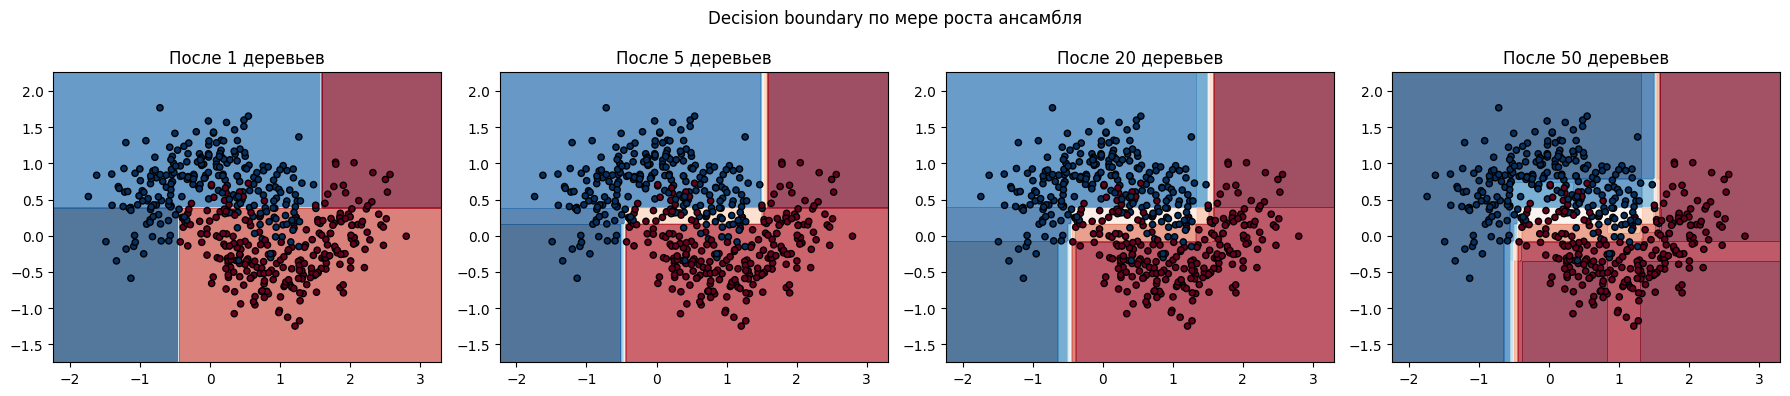

In [4]:
def predict_with_k_trees(trees, X, y_train, k, lr=0.3):
    p = np.clip(y_train.mean(), 1e-6, 1-1e-6)
    F = np.full(len(X), np.log(p / (1 - p)))
    for t in trees[:k]:
        F += lr * t.predict(X)
    return 1 / (1 + np.exp(-F))

xx, yy = np.meshgrid(np.linspace(X2[:,0].min()-0.5, X2[:,0].max()+0.5, 200), np.linspace(X2[:,1].min()-0.5, X2[:,1].max()+0.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

stages = [1, 5, 20, 50]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, k in zip(axes, stages):
    Z = predict_with_k_trees(trees, grid, y2, k).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap="RdBu_r", alpha=0.7)
    ax.scatter(X2[:,0], X2[:,1], c=y2, edgecolor="k", cmap="RdBu_r", s=20)
    ax.set_title(f"После {k} деревьев")
plt.suptitle("Decision boundary по мере роста ансамбля")
plt.tight_layout()
plt.show()


### Как каждое следующее дерево уменьшает ошибку

Построим log-loss на train после каждого добавленного дерева.


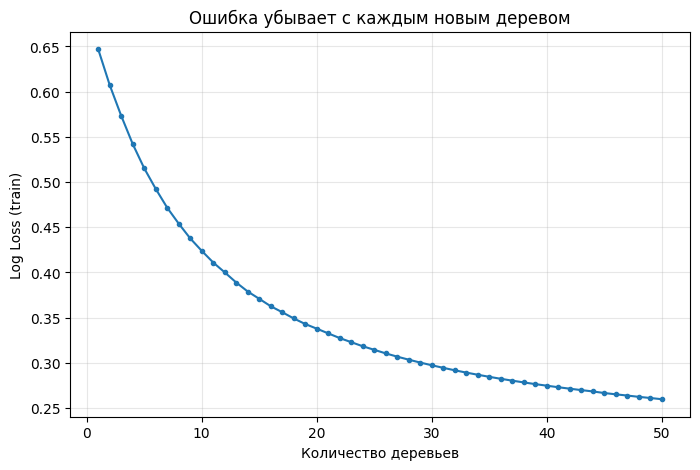

In [5]:
losses = []
for k in range(1, len(trees) + 1):
    p = predict_with_k_trees(trees, X2, y2, k)
    losses.append(log_loss(y2, np.clip(p, 1e-6, 1-1e-6)))

plt.plot(range(1, len(losses)+1), losses, marker="o", ms=3)
plt.xlabel("Количество деревьев")
plt.ylabel("Log Loss (train)")
plt.title("Ошибка убывает с каждым новым деревом")
plt.grid(alpha=0.3)
plt.show()


## 3. Обучаем модель на основном датасете


In [6]:
model = LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=-1, num_leaves=31, random_state=42, verbose=-1)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 4. Метрики качества


In [7]:
metrics = {
    "Accuracy":  accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall":    recall_score(y_test, y_pred),
    "F1-score":  f1_score(y_test, y_pred),
    "ROC-AUC":   roc_auc_score(y_test, y_proba),
    "Log Loss":  log_loss(y_test, y_proba),
}
pd.DataFrame(metrics, index=["value"]).T.round(4)


,value
Accuracy,0.9400
Precision,0.9583
Recall,0.9200
F1-score,0.9388
ROC-AUC,0.9807
Log Loss,0.1884


## 5. Confusion matrix и ROC-кривая


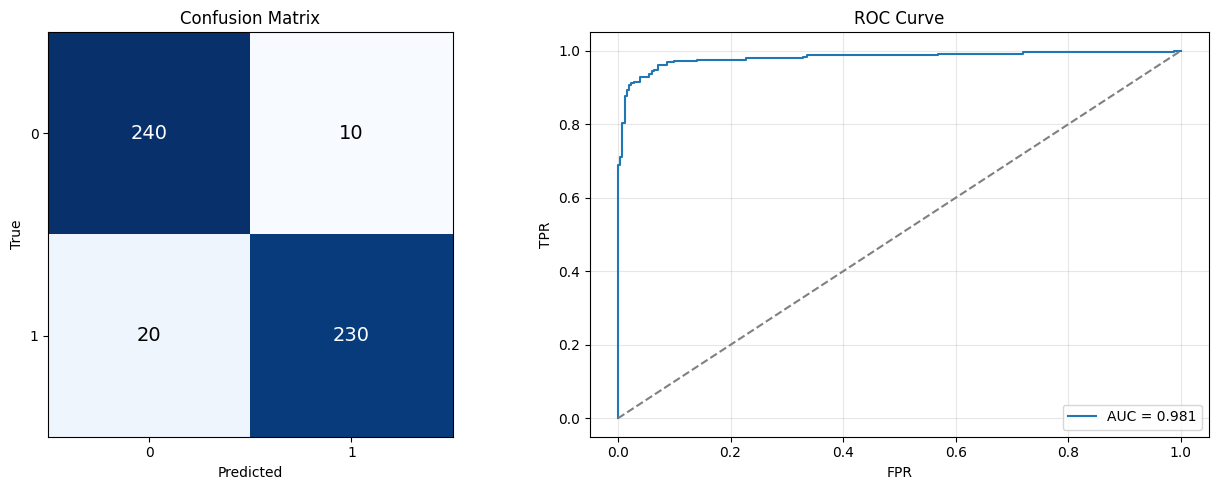

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
axes[0].imshow(cm, cmap="Blues")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC Curve"); axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 6. Feature importance


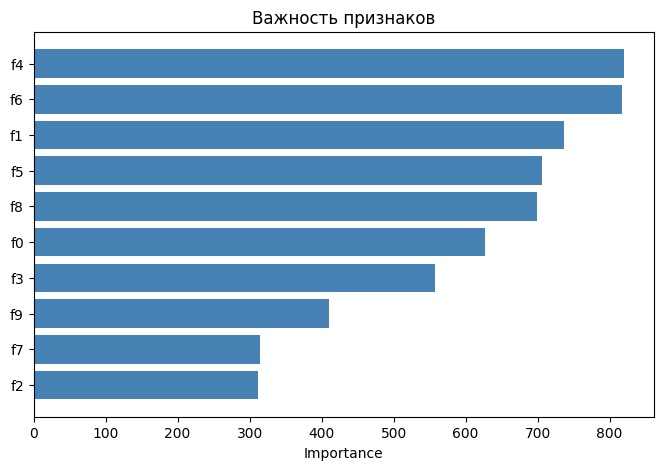

In [9]:
importances = model.feature_importances_

idx = np.argsort(importances)
plt.barh(np.array(feature_names)[idx], importances[idx], color="steelblue")
plt.title("Важность признаков")
plt.xlabel("Importance")
plt.show()


## 7. Качество при разном количестве деревьев


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

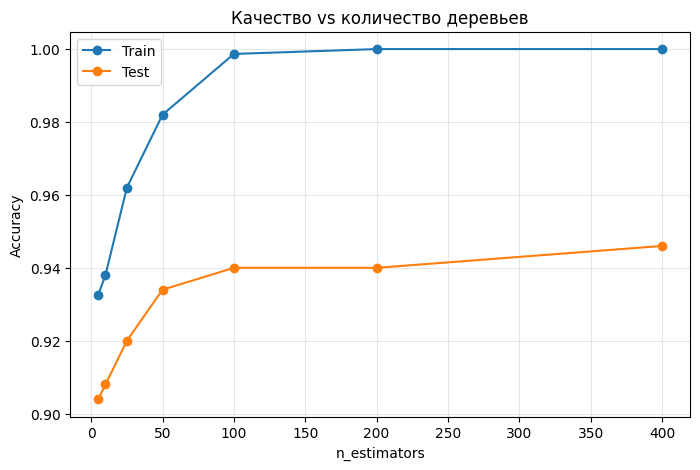

In [10]:
n_list = [5, 10, 25, 50, 100, 200, 400]
acc_train, acc_test = [], []

for n in n_list:
    m = LGBMClassifier(n_estimators=n, learning_rate=0.05, random_state=42, verbose=-1)
    m.fit(X_train, y_train)
    acc_train.append(accuracy_score(y_train, m.predict(X_train)))
    acc_test.append(accuracy_score(y_test, m.predict(X_test)))

plt.plot(n_list, acc_train, "o-", label="Train")
plt.plot(n_list, acc_test, "o-", label="Test")
plt.xlabel("n_estimators"); plt.ylabel("Accuracy")
plt.title("Качество vs количество деревьев")
plt.legend(); plt.grid(alpha=0.3); plt.show()


## 8. Влияние `learning_rate` и `max_depth`


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

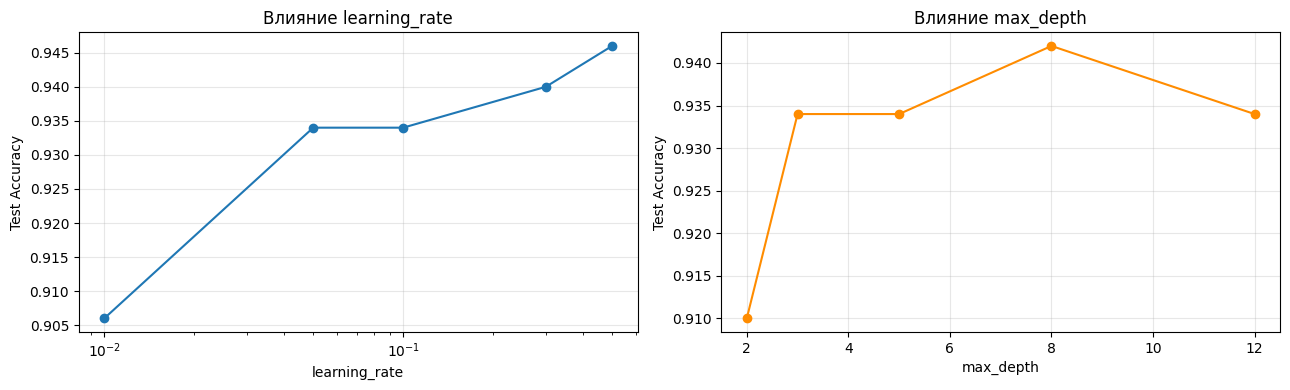

In [11]:
def fit_score(n_estimators=100, learning_rate=0.1, max_depth=6):
    m = LGBMClassifier(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, num_leaves=31, random_state=42, verbose=-1)
    m.fit(X_train, y_train)
    return accuracy_score(y_test, m.predict(X_test))

lrs = [0.01, 0.05, 0.1, 0.3, 0.5]
depths = [2, 3, 5, 8, 12]

acc_lr    = [fit_score(learning_rate=lr) for lr in lrs]
acc_depth = [fit_score(max_depth=d)      for d in depths]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(lrs, acc_lr, "o-"); axes[0].set_xscale("log")
axes[0].set_title("Влияние learning_rate")
axes[0].set_xlabel("learning_rate"); axes[0].set_ylabel("Test Accuracy")
axes[0].grid(alpha=0.3)

axes[1].plot(depths, acc_depth, "o-", color="darkorange")
axes[1].set_title("Влияние max_depth")
axes[1].set_xlabel("max_depth"); axes[1].set_ylabel("Test Accuracy")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 9. Learning curve


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

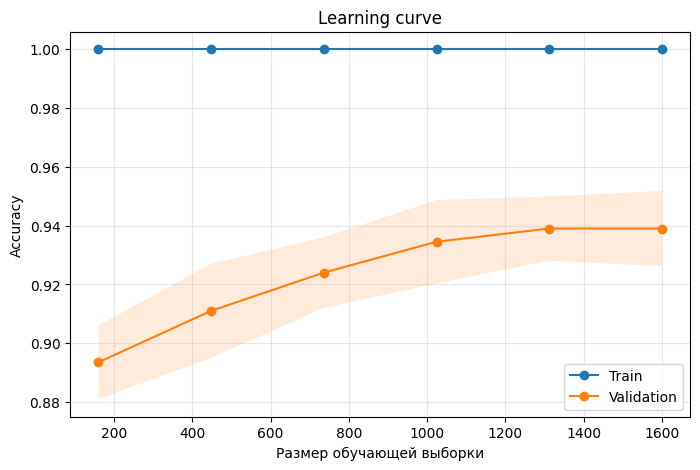

In [12]:
base = LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1)

sizes, train_scores, val_scores = learning_curve(
    base, X, y, cv=5, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 6), random_state=42
)

plt.plot(sizes, train_scores.mean(axis=1), "o-", label="Train")
plt.plot(sizes, val_scores.mean(axis=1),   "o-", label="Validation")
plt.fill_between(sizes, train_scores.mean(1)-train_scores.std(1), train_scores.mean(1)+train_scores.std(1), alpha=0.15)
plt.fill_between(sizes, val_scores.mean(1)-val_scores.std(1), val_scores.mean(1)+val_scores.std(1), alpha=0.15)
plt.xlabel("Размер обучающей выборки"); plt.ylabel("Accuracy")
plt.title("Learning curve"); plt.legend(); plt.grid(alpha=0.3)
plt.show()


#**Общий итог:**

- Бустинг строит деревья **последовательно**, каждое исправляет ошибки предыдущих.
- `n_estimators` — больше деревьев → выше качество, но риск переобучения.
- `learning_rate` — меньше шаг → стабильнее обучение, но нужно больше деревьев.
- `max_depth` — слишком глубокие деревья переобучаются.
- На практике эти три параметра подбирают **вместе** (например, через grid/random search).
